In [3]:
%run "02.1_utls.ipynb"

(5410, 36)
(4328, 34)
(1082, 34)
PotentialFraud
0    3923
1     405
Name: count, dtype: int64
PotentialFraud
0    981
1    101
Name: count, dtype: int64


In [4]:
# Import required libraries for machine learning and data analysis
from sklearn.preprocessing import MinMaxScaler  # For feature scaling (0-1 normalization)
from sklearn.linear_model import LogisticRegression  # For logistic regression classification model
from sklearn.ensemble import IsolationForest  # For anomaly detection and outlier removal
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve, roc_auc_score, precision_recall_curve,auc  # For model evaluation metrics
import matplotlib.pyplot as plt  # For plotting visualizations

### Outlier Removal

In [5]:
# Print the shape of the training data before outlier removal
print(x_train.shape)
# Initialize Isolation Forest with 0.5% contamination rate (to detect 0.5% of data as outliers)
clf = IsolationForest(contamination= 0.005)
# Combine features and target variable into a single dataframe for outlier detection
outlier_removal_df = pd.concat([x_train,y_train],axis = 1).reset_index(drop = True)
# Fit the Isolation Forest model on the combined data
clf.fit(outlier_removal_df)
# Get predictions: 1 for inliers, -1 for outliers
predictions = clf.predict(outlier_removal_df)
# Keep only the rows where predictions equal 1 (inliers) and reset index
x_train_cleaned = outlier_removal_df[np.where(predictions == 1, True, False)].reset_index(drop = True).copy()
# Extract features from the cleaned data
x_train = x_train_cleaned.drop(columns = 'PotentialFraud')
# Extract target from the cleaned data
y_train = x_train_cleaned['PotentialFraud']
# Print the shape of training data after outlier removal
print(x_train.shape)

(4328, 34)
(4306, 34)


In [6]:
# Display the shape of the cleaned training data
x_train_cleaned.shape

(4306, 35)

In [7]:
# Display the count distribution of target variable in test set (after cleaning)
y_test.value_counts()

PotentialFraud
0    981
1    101
Name: count, dtype: int64

### Scaling

In [8]:
# Initialize MinMaxScaler to scale features to the range [0, 1]
scaler=MinMaxScaler()
# Fit the scaler on training data and apply the transformation
x_train=scaler.fit_transform(x_train)
# Apply the same transformation to test data (using parameters learned from training data)
x_test=scaler.transform(x_test)

### Loading Logistic Regression Model

In [9]:
# Initialize Logistic Regression model with maximum iterations set to 1000
lr_estimate = LogisticRegression(max_iter = 1000,  # Maximum iterations for convergence
                                # penalty = 'l1',  # (Optional) L1 regularization
                                 #solver = 'liblinear',  # (Optional) Solver type
                                 #C = 1.8,  # (Optional) Inverse regularization strength
                                #class_weight={0:0.35,1:0.65},  # (Optional) Class weights for handling imbalance
                                random_state = 42)  # Random seed for reproducibility
# Train the logistic regression model on scaled training data
lr_estimate.fit(x_train,y_train)
# Make binary predictions (0 or 1) on the test set
y_pred = lr_estimate.predict(x_test)
# Get predicted probabilities for the positive class (fraud probability)
y_prob = lr_estimate.predict_proba(x_test)[:, 1]
# Print classification metrics report showing precision, recall, and f1-score
print("*****Classification Rport********")
print(classification_report(y_test,y_pred))
# Print confusion matrix showing true/false positives and negatives
print("**** Confusion Matrix ***********")
print(confusion_matrix(y_test,y_pred))

*****Classification Rport********
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       981
           1       0.82      0.45      0.58       101

    accuracy                           0.94      1082
   macro avg       0.88      0.72      0.77      1082
weighted avg       0.93      0.94      0.93      1082

**** Confusion Matrix ***********
[[971  10]
 [ 56  45]]


In [10]:
# Print the number of iterations used for model convergence
print(lr_estimate.n_iter_)

[39]


In [11]:
# Calculate accuracy score on the training data
Train_score = accuracy_score(y_train,lr_estimate.predict(x_train))
# Calculate accuracy score on the test data
Test_score = accuracy_score(y_test,y_pred)
# Print training set accuracy
print("Train_score: ", Train_score)
# Print test set accuracy
print("Test_score: ", Test_score)
# Calculate and print the overfitting percentage (difference between train and test accuracy)
print("over_fiting: ", (Train_score - Test_score)*100)

Train_score:  0.9275429633070135
Test_score:  0.9390018484288355
over_fiting:  -1.1458885121822027


In [12]:
# Extract coefficients from the trained logistic regression model
coefficients = lr_estimate.coef_[0]

# Create a dataframe showing feature names and their coefficients
feature_importance = pd.DataFrame({
    'Feature': X_var.columns,  # Feature names from the original dataframe
    'Coefficient': coefficients,  # Coefficient values
    'abs_Coefficients': abs(coefficients)  # Absolute values for sorting
})
# Sort the dataframe by absolute coefficient values in descending order (most important features first)
feature_importance = feature_importance.sort_values(by = 'abs_Coefficients', ascending = False)

In [13]:
# Display the feature importance dataframe with coefficients and absolute coefficients
feature_importance

,Feature,Coefficient,abs_Coefficients
0,IP_Claim_Count,4.911621,4.911621
1,IP_Benf_Count,4.297909,4.297909
8,OP_Claim_Count,3.160781,3.160781
2,Avg_IP_InscClaimAmtReimbursed,2.695519,2.695519
4,Avg_IP_Number_of_Days_in_Hospital,-1.558452,1.558452
5,Avg_IP_Claim_Days,-1.457758,1.457758
3,Avg_IP_DeductibleAmtPaid,1.141915,1.141915
9,OP_Benf_Count,-1.039697,1.039697
6,Avg_IP_Unique_Disease_Count,0.922634,0.922634
30,Avg_IP_Reimbursement,0.810773,0.810773


### ROC and PR Curves

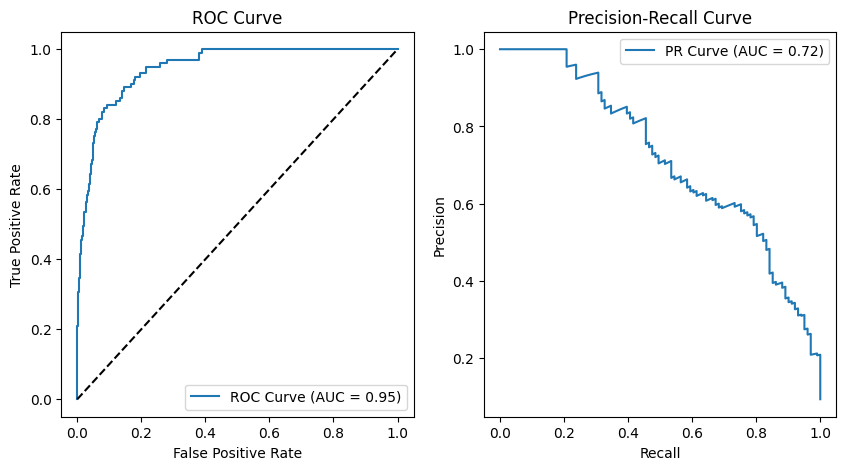

In [14]:
# Calculate false positive rate and true positive rate for ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
# Calculate area under the ROC curve (AUC-ROC score)
roc_auc = auc(fpr, tpr)

# Calculate precision and recall values for Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
# Calculate area under the Precision-Recall curve
pr_auc = auc(recall, precision)

# Create a figure with two subplots side by side
plt.figure(figsize=(10, 5))
# Plot ROC Curve in the first subplot
plt.subplot(1, 2, 1)
# Plot the ROC curve line with AUC score in legend
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
# Plot the diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--')
# Label x-axis
plt.xlabel('False Positive Rate')
# Label y-axis
plt.ylabel('True Positive Rate')
# Set plot title
plt.title('ROC Curve')
# Add legend
plt.legend()

# Plot Precision-Recall Curve in the second subplot
plt.subplot(1, 2, 2)
# Plot the PR curve line with AUC score in legend
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
# Label x-axis
plt.xlabel('Recall')
# Label y-axis
plt.ylabel('Precision')
# Set plot title
plt.title('Precision-Recall Curve')
# Add legend
plt.legend()
# Display the plots
plt.show()